# Lesson 14 activity: advanced statistics

## Learning objectives

This activity will help you to:

1. Apply appropriate statistical tests to real-world data
2. Interpret hypothesis test results and p-values
3. Compare multiple groups using statistical methods
4. Make data-driven conclusions based on statistical evidence

## Setup

Import the required libraries and load the weather dataset.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

In [3]:
# Load the weather dataset
url = 'https://github.com/gperdrizet/fullstack-2605/raw/main/data/weather.csv'
df = pd.read_csv(url)

## Exercise 1: Humidity Differences Among Weather Conditions

**Objective**: Determine if humidity is significantly different among different weather conditions.

**Background**: 
The weather dataset contains humidity measurements for different weather conditions (Sunny, Rainy, Cloudy, etc.). We want to know if these weather conditions are associated with significantly different humidity levels.

**Tasks**:

1. **Explore the data**:
   - Check how many unique weather conditions are in the dataset
   - Calculate the mean and standard deviation of humidity for each weather condition
   - Create a boxplot showing the humidity distribution for each weather condition
   - Based on the visualization, do you think the humidity levels differ significantly?

2. **Choose an appropriate statistical test**:
   - Since we're comparing humidity across multiple groups (weather conditions), what test should we use?
   - Hint: Consider ANOVA (Analysis of Variance) or Kruskal-Wallis test
   - State your null and alternative hypotheses

3. **Check assumptions** (if using ANOVA):
   - Are the sample sizes roughly equal across groups?
   - Use a visualization or test to check if the data appears roughly normally distributed
   - Check for equal variances across groups (you can use a simple visual check or Levene's test)

4. **Perform the statistical test**:
   - Conduct the chosen test using scipy.stats
   - Report the test statistic and p-value
   - Using α = 0.05, determine whether to reject or accept the null hypothesis

5. **Interpret the results**:
   - What does your test result tell you about humidity and weather conditions?
   - If you rejected the null hypothesis, which weather conditions appear to have different humidity levels? (Use the boxplot and descriptive statistics to support your conclusion)
   - What are the practical implications of this finding?

**Bonus**: 
- If you found a significant difference, perform post-hoc pairwise comparisons to determine which specific weather conditions differ from each other
- Consider whether Bonferroni correction should be applied to the pairwise comparisons

In [4]:
# Your code here
# Task 1: Explore humidity across weather conditions

# How many groups are we comparing? This determines the test family.
# Two groups -> t-test. Three or more -> ANOVA or Kruskal-Wallis.
conditions = df['weather_condition'].unique()
print(f'Weather conditions ({len(conditions)}): {conditions}')
print()

# Mean and std per group. The std matters as much as the mean:
# ANOVA judges whether group means are far apart RELATIVE to within-group noise.
summary = df.groupby('weather_condition')['humidity_percent'].agg(['count', 'mean', 'std'])
print(summary)

Weather conditions (4): ['Sunny' 'Snowy' 'Rainy' 'Cloudy']

                   count       mean        std
weather_condition                             
Cloudy               107  67.741121  12.334473
Rainy                 71  85.812676  10.342104
Snowy                 34  79.673529  10.793273
Sunny                153  52.985621  14.754123


/tmp/ipykernel_56118/693883309.py:6: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(groups, labels=conditions)


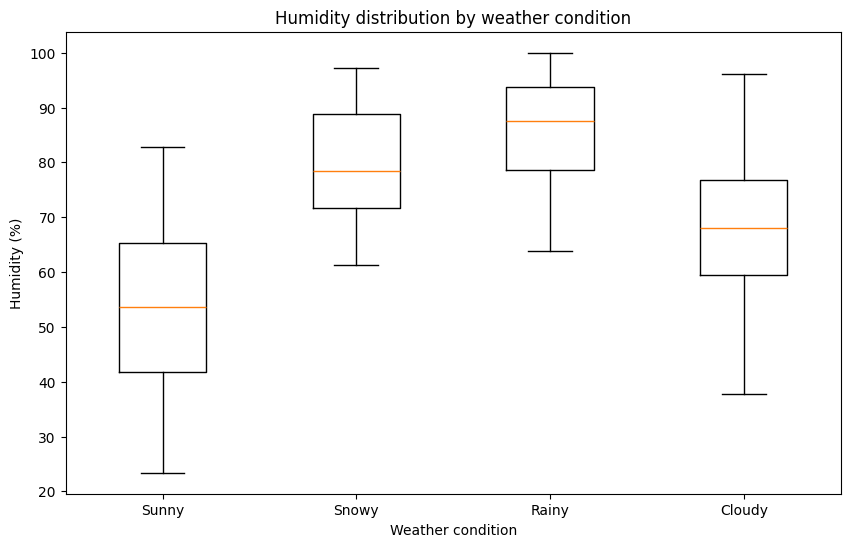

In [5]:
# Visual first. If the boxes barely overlap, expect a significant result.
# If they sit on top of each other, expect a large p-value.
groups = [df[df['weather_condition'] == c]['humidity_percent'] for c in conditions]

fig, ax = plt.subplots(figsize=(10, 6))
ax.boxplot(groups, labels=conditions)
ax.set_xlabel('Weather condition')
ax.set_ylabel('Humidity (%)')
ax.set_title('Humidity distribution by weather condition')
plt.show()

In [9]:
# Task 3: ANOVA assumes (1) roughly normal data within groups and
# (2) roughly equal variances across groups. If these fail badly,
# fall back to Kruskal-Wallis, which uses ranks and does not care.

# Normality check: Shapiro-Wilk per group.
# Null hypothesis here is "data IS normal", so p > 0.05 is the GOOD outcome.
print('Shapiro-Wilk normality test per group:')
for c, g in zip(conditions, groups):
    stat, p = stats.shapiro(g)
    print(f'  {c}: W = {stat:.4f}, p = {p:.4f} {"(looks normal)" if p > 0.05 else "(NOT normal)"}')
print()

# Equal variance check: Levene's test.
# Again the null is "variances are equal", so p > 0.05 is the good outcome.
stat, p = stats.levene(*groups)
print(f'Levene test for equal variances: stat = {stat:.4f}, p = {p:.4f}')
print('Variances look equal' if p > 0.05 else 'Variances differ, prefer Kruskal-Wallis')

Shapiro-Wilk normality test per group:
  Sunny: W = 0.9719, p = 0.0032 (NOT normal)
  Snowy: W = 0.9480, p = 0.1070 (looks normal)
  Rainy: W = 0.9423, p = 0.0027 (NOT normal)
  Cloudy: W = 0.9916, p = 0.7537 (looks normal)

Levene test for equal variances: stat = 7.5783, p = 0.0001
Variances differ, prefer Kruskal-Wallis


In [10]:
# Task 4: Run both. If assumptions held, report ANOVA.
# If not, report Kruskal-Wallis. Running both also shows whether
# the conclusion is robust to the choice of test.

# H0: all weather conditions have the same mean humidity
# Ha: at least one condition has a different mean humidity

alpha = 0.05

f_stat, p_anova = stats.f_oneway(*groups)
print(f'One-way ANOVA:    F = {f_stat:.4f}, p = {p_anova:.6f}')

h_stat, p_kw = stats.kruskal(*groups)
print(f'Kruskal-Wallis:   H = {h_stat:.4f}, p = {p_kw:.6f}')
print()

if p_anova < alpha:
    print(f'p < {alpha}: reject H0. At least one condition has significantly different humidity.')
else:
    print(f'p >= {alpha}: fail to reject H0. No evidence the conditions differ in humidity.')

One-way ANOVA:    F = 120.1495, p = 0.000000
Kruskal-Wallis:   H = 185.5009, p = 0.000000

p < 0.05: reject H0. At least one condition has significantly different humidity.


In [11]:
# Task 5 / Bonus: ANOVA only says "at least one group differs", not which one.
# Pairwise t-tests find the specific pairs, but each test carries a 5%
# false positive risk and those risks compound. Bonferroni fixes this by
# dividing alpha by the number of comparisons.

from itertools import combinations

pairs = list(combinations(range(len(conditions)), 2))
alpha_corrected = alpha / len(pairs)
print(f'{len(pairs)} pairwise comparisons, Bonferroni-corrected alpha = {alpha_corrected:.4f}')
print()

for i, j in pairs:
    t_stat, p = stats.ttest_ind(groups[i], groups[j])
    sig = 'SIGNIFICANT' if p < alpha_corrected else 'not significant'
    print(f'{conditions[i]:>10} vs {conditions[j]:<10} t = {t_stat:7.3f}, p = {p:.6f}  {sig}')

6 pairwise comparisons, Bonferroni-corrected alpha = 0.0083

     Sunny vs Snowy      t =  -9.962, p = 0.000000  SIGNIFICANT
     Sunny vs Rainy      t = -16.909, p = 0.000000  SIGNIFICANT
     Sunny vs Cloudy     t =  -8.477, p = 0.000000  SIGNIFICANT
     Snowy vs Rainy      t =  -2.806, p = 0.005991  SIGNIFICANT
     Snowy vs Cloudy     t =   5.057, p = 0.000001  SIGNIFICANT
     Rainy vs Cloudy     t =  10.192, p = 0.000000  SIGNIFICANT


## Exercise 2: Testing for Association Between Weather Condition and Wind Strength

**Objective**: Determine if there is a significant association (non-random relationship) between weather condition and wind strength.

**Background**: 
If weather conditions and wind strength are independent, we would expect days to be randomly distributed across all combinations of weather condition and wind strength. However, certain weather conditions might be more likely to occur with certain wind strengths (e.g., rainy days might be associated with stronger winds). We can use a chi-square test of independence to test this.

**Tasks**:

1. **Explore the data**:
   - Check the unique values in both `weather_condition` and `wind_strength` columns
   - Count how many days fall into each category for both variables
   - Create a contingency table (crosstab) showing the count of days for each combination of weather condition and wind strength
   - Use `pd.crosstab(df['weather_condition'], df['wind_strength'])` to create this table

2. **Visualize the relationship**:
   - Create a heatmap of the contingency table to visualize the distribution of days
   - You can use `plt.imshow()` or `sns.heatmap()` if seaborn is available
   - Based on the visualization, do certain weather conditions appear to be associated with certain wind strengths?

3. **State your hypotheses**:
   - **Null hypothesis**: Weather condition and wind strength are independent (days are randomly distributed across combinations)
   - **Alternative hypothesis**: Weather condition and wind strength are associated (days are NOT randomly distributed)

4. **Perform a chi-square test of independence**:
   - Use `scipy.stats.chi2_contingency()` on your contingency table
   - This test compares the observed frequencies to expected frequencies if the variables were independent
   - Report the chi-square statistic, p-value, and degrees of freedom

5. **Interpret the results**:
   - Using α = 0.05, determine whether to reject or accept the null hypothesis
   - If you reject the null hypothesis, what does this mean in practical terms?

6. **Draw conclusions**: Are weather condition and wind strength independent or associated?

In [12]:
# Your code here
# Exercise 2, Task 1: explore the two categorical variables

# Chi-square works on counts, not means, so first I want to see what
# categories exist and how the days pile up across them.
print('Weather conditions:', df['weather_condition'].unique())
print('Wind strengths:', df['wind_strength'].unique())
print()

print('Days per wind strength:')
print(df['wind_strength'].value_counts())
print()

# The contingency table is the heart of this test. Each cell is the count
# of days with a given (weather_condition, wind_strength) combination.
contingency = pd.crosstab(df['weather_condition'], df['wind_strength'])
print('Contingency table (observed counts):')
print(contingency)

Weather conditions: ['Sunny' 'Snowy' 'Rainy' 'Cloudy']
Wind strengths: ['Light Breeze' 'Gale' 'Strong Wind' 'Calm' 'Moderate Wind']

Days per wind strength:
wind_strength
Light Breeze     121
Moderate Wind     98
Calm              66
Strong Wind       55
Gale              25
Name: count, dtype: int64

Contingency table (observed counts):
wind_strength      Calm  Gale  Light Breeze  Moderate Wind  Strong Wind
weather_condition                                                      
Cloudy               14     7            43             27           16
Rainy                15     5            22             16           13
Snowy                 5     4            13             10            2
Sunny                32     9            43             45           24


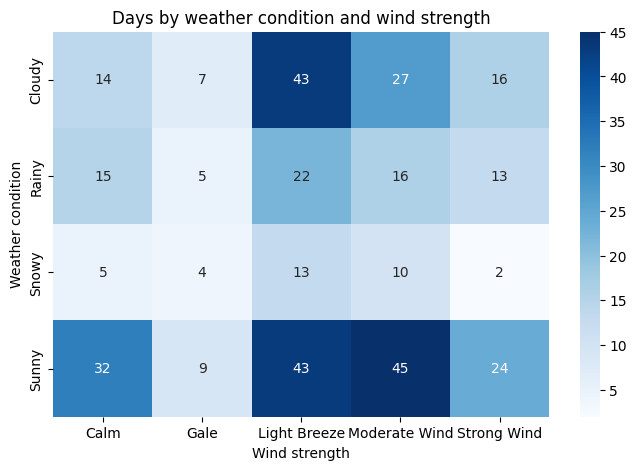

In [13]:
# Task 2: visualize the table so associations jump out. annot=True prints
# the actual count in each cell, which makes the table readable at a glance.
import seaborn as sns

fig, ax = plt.subplots(figsize=(8, 5))
sns.heatmap(contingency, annot=True, fmt='d', cmap='Blues', ax=ax)
ax.set_title('Days by weather condition and wind strength')
ax.set_xlabel('Wind strength')
ax.set_ylabel('Weather condition')
plt.show()

In [14]:
# Tasks 3-5: hypotheses, test, interpretation.
# H0: weather condition and wind strength are independent
# Ha: they are associated (days are NOT randomly distributed)

alpha = 0.05
chi2, p, dof, expected = stats.chi2_contingency(contingency)

print(f'Chi-square statistic: {chi2:.4f}')
print(f'Degrees of freedom:   {dof}')
print(f'P-value:              {p:.6f}')
print()

# Assumption check: chi-square is only trustworthy when the expected counts
# are not too small. Rule of thumb is every expected cell should be >= 5.
expected_df = pd.DataFrame(expected, index=contingency.index, columns=contingency.columns)
print('Expected counts if independent:')
print(expected_df.round(1))
print()
min_expected = expected.min()
print(f'Smallest expected count: {min_expected:.1f}',
      '(OK)' if min_expected >= 5 else '(WARNING: below 5, test may be unreliable)')
print()

if p < alpha:
    print(f'p < {alpha}: reject H0. Weather condition and wind strength ARE associated.')
else:
    print(f'p >= {alpha}: fail to reject H0. No evidence of association.')

Chi-square statistic: 10.7934
Degrees of freedom:   12
P-value:              0.546705

Expected counts if independent:
wind_strength      Calm  Gale  Light Breeze  Moderate Wind  Strong Wind
weather_condition                                                      
Cloudy             19.3   7.3          35.5           28.7         16.1
Rainy              12.8   4.9          23.5           19.1         10.7
Snowy               6.1   2.3          11.3            9.1          5.1
Sunny              27.7  10.5          50.7           41.1         23.1

Smallest expected count: 2.3 (WARNING: below 5, test may be unreliable)

p >= 0.05: fail to reject H0. No evidence of association.


## Exercise 3: Testing for Relationship Between Humidity and Pressure

**Objective**: Determine if there is a significant linear relationship between humidity (%) and atmospheric pressure (hPa).

**Background**: 
When working with two continuous variables, we can test whether they are correlated. Correlation measures the strength and direction of a linear relationship. In meteorology, understanding relationships between variables like humidity and pressure can help improve weather predictions.

**Tasks**:

1. **Explore the data**:
   - Check for any missing values in `humidity_percent` and `pressure_hpa`
   - Calculate basic descriptive statistics (mean, std, min, max) for both variables
   - Create a scatter plot of humidity vs. pressure
   - Based on the visualization, do you think there's a relationship? If so, is it positive or negative?

2. **Choose an appropriate correlation test**:
   - Since we have two continuous variables, we can use Pearson or Spearman correlation
   - Pearson correlation measures linear relationships and assumes normality
   - Spearman correlation measures monotonic relationships and is more robust
   - Check the distributions of both variables (histograms or Q-Q plots) to help decide
   - State your null and alternative hypotheses

3. **Perform the correlation test**:
   - Calculate both Pearson and Spearman correlation coefficients
   - Use `scipy.stats.pearsonr()` and `scipy.stats.spearmanr()`
   - Report the correlation coefficient (r) and p-value for each test
   - Using α = 0.05, determine whether the correlation is statistically significant

4. **Interpret the correlation coefficient**:
   - What is the direction of the relationship (positive or negative)?
   - What is the strength of the relationship? (Hint: |r| < 0.3 weak, 0.3-0.7 moderate, > 0.7 strong)
   - Calculate the coefficient of determination (r²) - what percentage of variance in one variable is explained by the other?

5. **Draw conclusions**:
   - Is there a statistically significant relationship between humidity and pressure?
   - Is the relationship strong enough to be practically useful?

Missing values:
humidity_percent    0
pressure_hpa        0
dtype: int64

Descriptive statistics:
       humidity_percent  pressure_hpa
count        365.000000    365.000000
mean          66.182740   1012.346301
std           18.232318      7.437610
min           23.400000    983.700000
25%           53.900000   1007.500000
50%           66.800000   1013.200000
75%           79.400000   1017.600000
max          100.000000   1039.000000



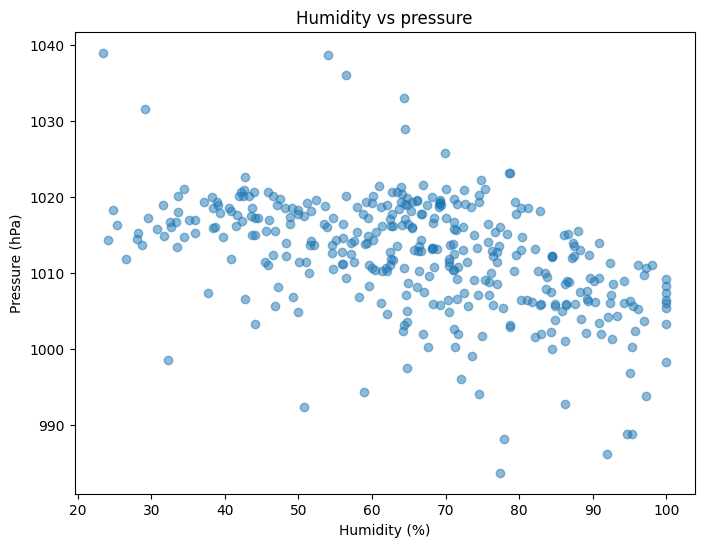

In [15]:
# Your code here
# Exercise 3, Task 1: explore the two continuous variables

# Correlation math breaks on missing values, so check first.
print('Missing values:')
print(df[['humidity_percent', 'pressure_hpa']].isnull().sum())
print()

print('Descriptive statistics:')
print(df[['humidity_percent', 'pressure_hpa']].describe())
print()

# The scatter plot tells me the shape before I trust any single number.
# I am looking for direction (up or down) and whether the cloud looks
# like a line, a curve, or a shapeless blob.
fig, ax = plt.subplots(figsize=(8, 6))
ax.scatter(df['humidity_percent'], df['pressure_hpa'], alpha=0.5)
ax.set_xlabel('Humidity (%)')
ax.set_ylabel('Pressure (hPa)')
ax.set_title('Humidity vs pressure')
plt.show()

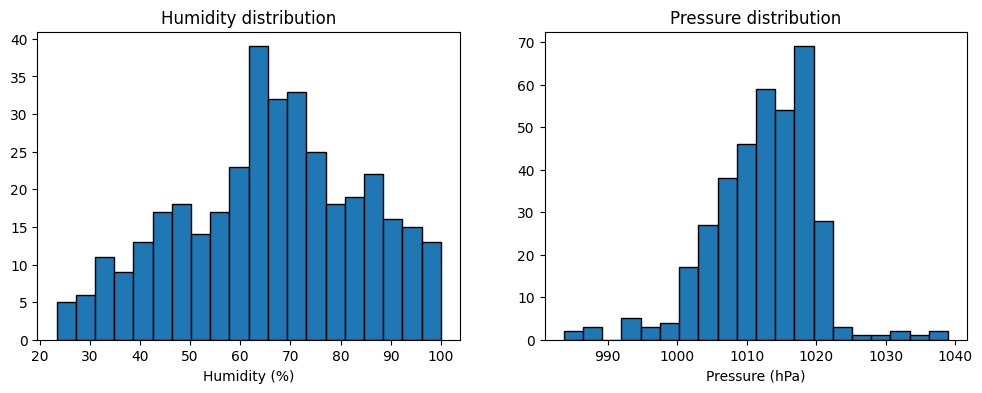

In [16]:
# Task 2: Pearson vs Spearman. Pearson assumes roughly normal and measures
# linear relationships. Spearman uses ranks, so it is robust to skew and
# catches any monotonic relationship. Histograms help me judge normality.
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(df['humidity_percent'], bins=20, edgecolor='black')
axes[0].set_title('Humidity distribution')
axes[0].set_xlabel('Humidity (%)')
axes[1].hist(df['pressure_hpa'], bins=20, edgecolor='black')
axes[1].set_title('Pressure distribution')
axes[1].set_xlabel('Pressure (hPa)')
plt.show()

In [17]:
# Tasks 3-5: run both, interpret direction, strength, and practical meaning.
# H0: no correlation between humidity and pressure (r = 0)
# Ha: there is a correlation (r != 0)

alpha = 0.05

pearson_r, pearson_p = stats.pearsonr(df['humidity_percent'], df['pressure_hpa'])
spearman_r, spearman_p = stats.spearmanr(df['humidity_percent'], df['pressure_hpa'])

print(f'Pearson:  r = {pearson_r:.4f}, p = {pearson_p:.6f}')
print(f'Spearman: r = {spearman_r:.4f}, p = {spearman_p:.6f}')
print()

# R-squared: the share of variance in one variable explained by the other.
# This is the practical-significance number, separate from the p-value.
r_squared = pearson_r ** 2
print(f'R-squared: {r_squared:.4f}  ({r_squared*100:.1f}% of variance explained)')
print()

abs_r = abs(pearson_r)
if abs_r < 0.3:
    strength = 'weak'
elif abs_r < 0.7:
    strength = 'moderate'
else:
    strength = 'strong'
direction = 'positive' if pearson_r > 0 else 'negative'

print(f'Direction: {direction}')
print(f'Strength:  {strength}')
print()

if pearson_p < alpha:
    print(f'p < {alpha}: statistically significant correlation.')
else:
    print(f'p >= {alpha}: no statistically significant correlation.')

Pearson:  r = -0.4710, p = 0.000000
Spearman: r = -0.5033, p = 0.000000

R-squared: 0.2218  (22.2% of variance explained)

Direction: negative
Strength:  moderate

p < 0.05: statistically significant correlation.
